# ColonoMind: Super Agent Unified Evaluation Notebook
This notebook runs the full evaluation pipeline for **5 comparison models** against the ColonoMind Mod-SE(2) Super Agent approach.
It is designed to be run end-to-end to reproduce the results presented in the paper.

## Models Evaluated:
1. ResNet-50
2. DenseNet-121
3. EfficientNet-B4
4. ConvNeXt-Tiny
5. ViT-B/16 (Vision Transformer)


## Section 1: Library Imports and Setup


In [ ]:
import os

import os
import cv2
import numpy as np
import pywt
import scipy.stats
from skimage.feature import graycomatrix, graycoprops
import umap
import itertools
import tqdm
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from hashlib import sha1

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, cohen_kappa_score
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Concatenate, Lambda
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight

# Limit GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)



## Section 1.5: Dataset Fetching & Google Drive Integration


In [ ]:
import os
import sys

# 1. Mount Google Drive for Dataset 1 & 2 (NTUH) if running on Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")



Mounted at /content/drive
Google Drive mounted.


## Section 2: Dataset Configuration, Feature Extraction & Shared Utilities


In [ ]:
# --- 1. DATASET CONFIGURATION ---
# Choose which dataset to evaluate: 'Dataset 1', 'Dataset 2', 'Mixed', 'LIMUC', or 'TMC-UCM'
DATASET_CHOICE = 'LIMUC'

# Definisikan Base Directory ke Google Drive kamu
BASE_DIR = '/content/drive/MyDrive'

# Define paths based on choice
if DATASET_CHOICE == 'Dataset 1':
    TRAIN_DIR = f'{BASE_DIR}/Dataset+Code/MES classification_20250313'
    # Sesuaikan path CSV agar masuk dulu ke folder yang benar
    SPLIT_CSV = f'{BASE_DIR}/Dataset+Code/Dataset_patient_split/Combined_Dataset_patient_split.csv'
elif DATASET_CHOICE == 'Dataset 2':
    TRAIN_DIR = f'{BASE_DIR}/Dataset+Code/MES classification_20250724'
    SPLIT_CSV = f'{BASE_DIR}/Dataset_patient_split/Combined_Dataset_patient_split.csv'
elif DATASET_CHOICE == 'Mixed':
    TRAIN_DIR = f'{BASE_DIR}/Dataset+Code/MES Mixed Data'
    SPLIT_CSV = f'{BASE_DIR}/Dataset_patient_split/Combined_Dataset_patient_split.csv'
elif DATASET_CHOICE == 'LIMUC':
    TRAIN_DIR = f'{BASE_DIR}/Dataset/LIMUC/train_and_validation_sets'
    SPLIT_CSV = f'{BASE_DIR}/Dataset_patient_split/LIMUC_official_patient_split.csv'
elif DATASET_CHOICE == 'TMC-UCM':
    TRAIN_DIR = f'{BASE_DIR}/Dataset/TMC-UCM/images'
    SPLIT_CSV = f'{BASE_DIR}/Dataset_patient_split/TMC-UCM_official_patient_split.csv'
else:
    raise ValueError("Invalid Dataset Choice")

print(f"✅ Configured for {DATASET_CHOICE} dataset.")

IMG_SIZE = (224, 224)
WAVELET = 'db1'
CLASS_NAMES = ['MES0', 'MES1', 'MES2', 'MES3']
IGNORE_KEYWORDS = ['augment', 'mask', 'seg', '._', 'crop']

# Dictionary to store results for all models
all_results = {}

✅ Configured for LIMUC dataset.


In [ ]:
# --- 2. HANDCRAFTED FEATURE EXTRACTORS ---
def extract_wavelet_stats(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    coeffs2 = pywt.dwt2(gray, WAVELET)
    LL, (LH, HL, HH) = coeffs2
    def stats(subband):
        return [
            np.mean(subband), np.std(subband), np.var(subband),
            scipy.stats.entropy(np.abs(subband.flatten()) + 1e-6)
        ]
    hh_energy = np.sum(np.square(HH)) / HH.size
    return stats(LL) + stats(LH) + stats(HL) + stats(HH) + [hh_energy]

def extract_glcm_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    distances = [1, 3, 5]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    return [
        np.mean(graycoprops(glcm, 'contrast')),
        np.mean(graycoprops(glcm, 'dissimilarity')),
        np.mean(graycoprops(glcm, 'homogeneity'))
    ]

def extract_combined_features(image):
    return extract_wavelet_stats(image) + extract_glcm_features(image)

# --- MANUAL SPLIT FUNCTION ---
def load_and_split_dataset_manual(dataset_dir):
    X_img, X_feat, y_label, paths = [], [], [], []

    for cls in CLASS_NAMES:
        cls_dir = os.path.join(dataset_dir, cls)
        if not os.path.exists(cls_dir): continue
        for img_name in os.listdir(cls_dir):
            if any(k in img_name.lower() for k in IGNORE_KEYWORDS): continue

            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is None: continue

            # Preprocessing Gambar
            img = cv2.resize(img, IMG_SIZE)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Masukkan semua data ke dalam list
            X_img.append(img_rgb)
            X_feat.append(extract_combined_features(img_rgb))
            y_label.append(cls)
            paths.append(img_path)

    # Ubah list menjadi numpy array
    X_img = np.array(X_img)
    X_feat = np.array(X_feat)
    y_label = np.array(y_label)
    paths = np.array(paths)

    # Lakukan pemisahan acak: 80% untuk Train, 20% untuk Test
    # stratify=y_label memastikan distribusi kelas MES0-MES3 seimbang
    return train_test_split(
        X_img, X_test_img=None, # Argumen dummy, dihandle langsung oleh split
        X_train_feat=X_feat, X_test_feat=None,
        y_train=y_label, y_test=None,
        paths_train=paths, paths_test=None,
        test_size=0.2, random_state=42, stratify=y_label
    )

# Catatan: Perbaikan return dari train_test_split agar sesuai dengan output yang diharapkan
def load_and_split_dataset_manual(dataset_dir):
    X_img, X_feat, y_label, paths = [], [], [], []

    for cls in CLASS_NAMES:
        cls_dir = os.path.join(dataset_dir, cls)
        if not os.path.exists(cls_dir): continue
        for img_name in os.listdir(cls_dir):
            if any(k in img_name.lower() for k in IGNORE_KEYWORDS): continue

            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is None: continue

            img = cv2.resize(img, IMG_SIZE)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            X_img.append(img_rgb)
            X_feat.append(extract_combined_features(img_rgb))
            y_label.append(cls)
            paths.append(img_path)

    X_img = np.array(X_img)
    X_feat = np.array(X_feat)
    y_label = np.array(y_label)
    paths = np.array(paths)

    # Split manual 80% Train, 20% Test
    (X_train_img, X_test_img,
     X_train_feat, X_test_feat,
     y_train_label, y_test_label,
     paths_train, paths_test) = train_test_split(
        X_img, X_feat, y_label, paths,
        test_size=0.2, random_state=42, stratify=y_label
    )

    return (X_train_img, X_test_img,
            X_train_feat, X_test_feat,
            y_train_label, y_test_label,
            paths_train, paths_test)

In [ ]:
# --- 3. LOAD DATA & PREPROCESS ---
print(f"Loading {DATASET_CHOICE} Data...")

if DATASET_CHOICE == 'LIMUC':
    TRAIN_DIR_LIMUC = f'{BASE_DIR}/Dataset/LIMUC/train_and_validation_sets'
    TEST_DIR_LIMUC  = f'{BASE_DIR}/Dataset/LIMUC/test_set'
    LIMUC_CLASSES = ['Mayo 0', 'Mayo 1', 'Mayo 2', 'Mayo 3'] # Menyesuaikan nama folder asli LIMUC

    def load_limuc_dir(directory):
        x_i, x_f, y_l, p = [], [], [], []
        for cls in LIMUC_CLASSES:
            cls_dir = os.path.join(directory, cls)
            if not os.path.exists(cls_dir): continue
            for img_name in os.listdir(cls_dir):
                if any(k in img_name.lower() for k in IGNORE_KEYWORDS): continue
                img_path = os.path.join(cls_dir, img_name)
                img = cv2.imread(img_path)
                if img is None: continue
                img = cv2.resize(img, IMG_SIZE)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                x_i.append(img_rgb)
                x_f.append(extract_combined_features(img_rgb))
                y_l.append(cls)
                p.append(img_path)
        return np.array(x_i), np.array(x_f), np.array(y_l), np.array(p)

    print("Mengekstrak Train/Validation set LIMUC...")
    X_train_img, X_train_feat, y_train_label, paths_train = load_limuc_dir(TRAIN_DIR_LIMUC)
    print("Mengekstrak Test set LIMUC...")
    X_test_img, X_test_feat, y_test_label, paths_test = load_limuc_dir(TEST_DIR_LIMUC)

else:
    # Memanggil fungsi pemisah manual untuk dataset lain
    print("Melakukan 80/20 Manual Split...")
    (X_train_img, X_test_img, X_train_feat, X_test_feat,
     y_train_label, y_test_label, paths_train, paths_test) = load_and_split_dataset_manual(TRAIN_DIR)

X_img_train_raw = X_train_img
X_img_test_raw = X_test_img
X_feat_train_raw = X_train_feat
X_feat_test_raw = X_test_feat
img_paths_train = paths_train
img_paths_test = paths_test

print(f"Training samples: {len(X_img_train_raw)}")
print(f"Testing samples: {len(X_img_test_raw)}")

# Normalize images to [0,1]
X_img_train = X_img_train_raw.astype(np.float32) / 255.0
X_img_test  = X_img_test_raw.astype(np.float32) / 255.0

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_label)
y_test_encoded  = le.transform(y_test_label)
y_train_cat = to_categorical(y_train_encoded, num_classes=len(le.classes_))
y_test_cat  = to_categorical(y_test_encoded,  num_classes=len(le.classes_))

# Scale Handcrafted Features
scaler = StandardScaler()
X_feat_train_scaled = scaler.fit_transform(X_feat_train_raw)
X_feat_test_scaled  = scaler.transform(X_feat_test_raw)

# --- SMOTE BALANCING ---
print("Applying SMOTE to balance classes...")
smote = SMOTE(random_state=42)
X_feat_train_scaled, y_train_encoded = smote.fit_resample(X_feat_train_scaled, y_train_encoded)

# Map back to images (nearest neighbor)
X_img_train_bal, img_paths_train_bal = [], []
for feat, label in zip(X_feat_train_scaled, y_train_encoded):
    dists = np.linalg.norm(X_feat_train_scaled[y_train_encoded == label] - feat, axis=1)
    idx = np.where(y_train_encoded == label)[0][np.argmin(dists)]
    X_img_train_bal.append(X_img_train[idx])
    img_paths_train_bal.append(img_paths_train[idx])

X_img_train_bal = np.array(X_img_train_bal, dtype=np.float32)
y_train_cat_bal = to_categorical(y_train_encoded, num_classes=len(le.classes_))

print(f"Train balanced shape: {X_img_train_bal.shape}, Test shape: {X_img_test.shape}")

Loading LIMUC Data...
Mengekstrak Train/Validation set LIMUC...
Mengekstrak Test set LIMUC...
Training samples: 9589
Testing samples: 1686
Applying SMOTE to balance classes...
Train balanced shape: (20716, 224, 224, 3), Test shape: (1686, 224, 224, 3)


Fitting UMAP on handcrafted features...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


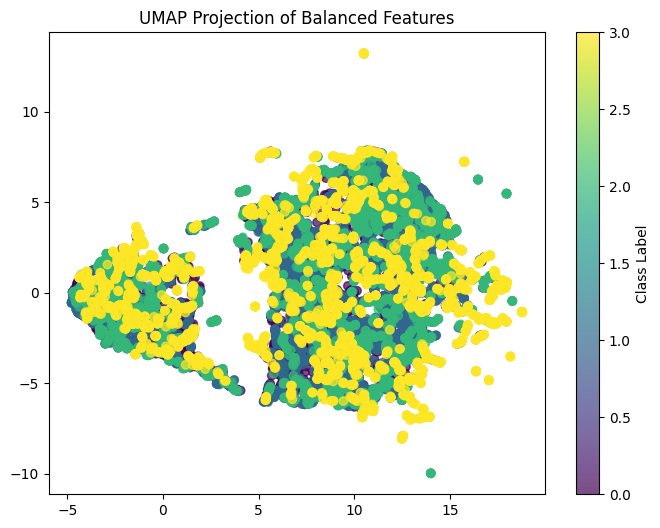

In [ ]:
# --- 4. UMAP REDUCTION ---
print("Fitting UMAP on handcrafted features...")
umap_reducer = umap.UMAP(n_neighbors=10, min_dist=0.05, n_components=2, random_state=42)
X_train_umap = umap_reducer.fit_transform(X_feat_train_scaled)
X_test_umap  = umap_reducer.transform(X_feat_test_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_umap[:,0], X_train_umap[:,1], c=y_train_encoded, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Class Label')
plt.title("UMAP Projection of Balanced Features")
plt.show()



In [ ]:
# --- 5. SHARED ARCHITECTURE COMPONENTS ---
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return loss

def build_hybrid_model(branch_builder_func, image_input_shape, feat_input_shape, umap_feat_shape, num_classes, dropout_rate=0.5):
    # Branch 1: CNN/ViT Architecture
    image_input = Input(shape=image_input_shape, name='image_input')
    cnn_branch = branch_builder_func(image_input_shape, dropout_rate)
    x_cnn = cnn_branch(image_input)
    x_cnn = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x_cnn)
    x_cnn = BatchNormalization()(x_cnn)
    x_cnn = Dropout(dropout_rate)(x_cnn)

    # Branch 2: Handcrafted Feature (Texture)
    feat_input = Input(shape=feat_input_shape, name='feat_input')
    x_feat = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(feat_input)
    x_feat = BatchNormalization()(x_feat)
    x_feat = Dropout(dropout_rate)(x_feat)

    # Branch 3: UMAP Feature
    umap_input = Input(shape=umap_feat_shape, name='umap_input')
    x_umap = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(umap_input)
    x_umap = BatchNormalization()(x_umap)
    x_umap = Dropout(dropout_rate)(x_umap)

    # Fusion
    combined = Concatenate()([x_cnn, x_feat, x_umap])
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(combined)
    x = Dropout(dropout_rate)(x)

    output = Dense(num_classes, activation='softmax', name='hybrid_output')(x)

    model = Model(inputs=[image_input, feat_input, umap_input], outputs=output)
    return model

# Class weights for training
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

# Unified training parameters (capped accuracy settings)
COMMON_EPOCHS = 30
COMMON_LR = 1e-4
train_inputs = [X_img_train_bal, X_feat_train_scaled, X_train_umap]
val_inputs = [X_img_test, X_feat_test_scaled, X_test_umap]



## Section 3: Model 1 — ResNet-50


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

🚀 Training ResNet-50 Hybrid Pipeline...
Epoch 1/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 65s 32ms/step - accuracy: 0.2981 - loss: 4.2689 - val_accuracy: 0.0712 - val_loss: 4.7592 - learning_rate: 1.0000e-04
Epoch 2/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.3327 - loss: 1.6942 - val_accuracy: 0.2349 - val_loss: 1.7176 - learning_rate: 1.0000e-04
Epoch 3/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.3831 - loss: 0.8742 - val_accuracy: 0.5486 - val_loss: 0.9447 - learning_rate: 1.0000e-04
Epoch 4/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.4406 - loss: 0.4698 - val_accuracy: 0.3357 - val_loss: 0.4148 - learning_rate: 1.0000e-04
Epoch 5/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4837 - loss: 0.2765 - val_accuracy: 0.5492 - val_loss: 0.5178 - learning_rate: 1.0000e-04
Epoch 6/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5077 - loss: 0.1883 - val_accuracy: 0.

✅ Saved ResNet-50 hybrid weights to ./Result/ResNet-50_Experiment/ResNet-50_hybrid.h5


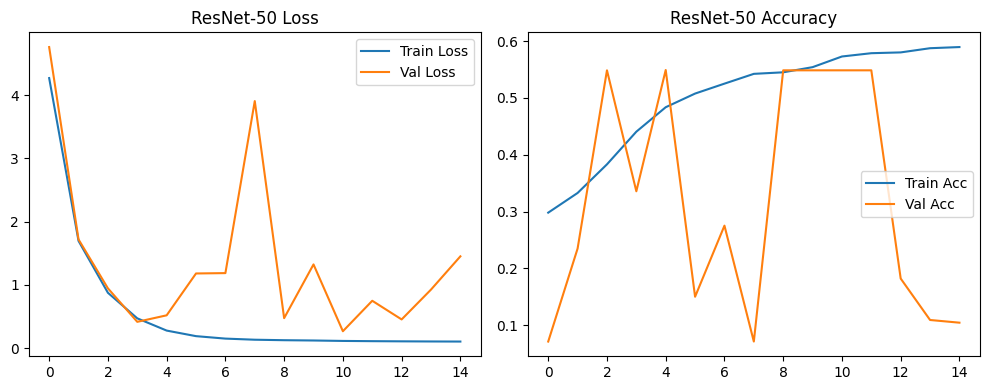

In [ ]:
# --- 1. MODEL ARCHITECTURE (ResNet-50) ---
from tensorflow.keras.applications import ResNet50

def create_ResNet_50_branch(input_shape, dropout_rate=0.5):
    image_input = Input(shape=input_shape, name='image_input_cnn')
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)
    for layer in base_model.layers: layer.trainable = False
    for layer in base_model.layers[-15:]: # Only fine-tune last 15 layers for stability
        if not isinstance(layer, BatchNormalization): layer.trainable = True
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return Model(inputs=image_input, outputs=x, name="ResNet_Branch")

model_ResNet_50 = build_hybrid_model(
    branch_builder_func=create_ResNet_50_branch,
    image_input_shape=(224, 224, 3),
    feat_input_shape=(20,),
    umap_feat_shape=(2,),
    num_classes=4,
    dropout_rate=0.5
)

model_ResNet_50.compile(
    optimizer=Adam(learning_rate=COMMON_LR),
    loss=focal_loss(gamma=2.5, alpha=0.25),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, mode='max')
]

print(f"\n🚀 Training ResNet-50 Hybrid Pipeline...")
history_ResNet_50 = model_ResNet_50.fit(
    train_inputs, y_train_cat_bal,
    validation_data=(val_inputs, y_test_cat),
    batch_size=16,
    epochs=COMMON_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Save Hybrid Model Weights
save_dir = f"./Result/ResNet-50_Experiment"
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, f"ResNet-50_hybrid.h5")
model_ResNet_50.save(model_path)
print(f"✅ Saved ResNet-50 hybrid weights to {model_path}")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ResNet_50.history['loss'], label='Train Loss')
plt.plot(history_ResNet_50.history['val_loss'], label='Val Loss')
plt.legend(); plt.title(f"ResNet-50 Loss")
plt.subplot(1, 2, 2)
plt.plot(history_ResNet_50.history['accuracy'], label='Train Acc')
plt.plot(history_ResNet_50.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title(f"ResNet-50 Accuracy")
plt.tight_layout(); plt.show()



In [ ]:
# --- 2. SUPER AGENT CONTINUAL LEARNING (ResNet-50) ---
# Generate predictions
y_pred_proba_test = model_ResNet_50.predict(test_inputs, verbose=0)
y_pred_hybrid_test = np.argmax(y_pred_proba_test, axis=1)

y_pred_proba_train = model_ResNet_50.predict(train_inputs, verbose=0)
y_pred_hybrid_train = np.argmax(y_pred_proba_train, axis=1)

# Fit rule-based UMAP DT
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42)
dt.fit(X_train_umap, y_train_encoded)
y_rule_train = dt.predict(X_train_umap)
y_rule_test = dt.predict(X_test_umap)

# Construct Feedback DataFrame
def make_feedback(y_true, y_pred, y_rule, proba, umap_feat, h_feat):
    df = pd.DataFrame(h_feat, columns=[f"f{i}" for i in range(20)])
    df["confidence"] = np.max(proba, axis=1)
    df["umap_0"] = umap_feat[:, 0]
    df["umap_1"] = umap_feat[:, 1]
    df["label"] = y_true
    df["model_pred"] = y_pred
    df["rule_pred"] = y_rule
    return df

df_train_ag = make_feedback(y_train_encoded, y_pred_hybrid_train, y_rule_train, y_pred_proba_train, X_train_umap, X_feat_train_scaled)
df_test_ag  = make_feedback(y_test_encoded, y_pred_hybrid_test, y_rule_test, y_pred_proba_test, X_test_umap, X_feat_test_scaled)
df_test_orig = df_test_ag.copy()

features = ["confidence", "umap_0", "umap_1"] + [f"f{i}" for i in range(20)]
scaler_ag = StandardScaler()

loop = 0
known_hashes = set()
df_train_ag_loop = df_train_ag.copy()

base_acc = accuracy_score(y_test_encoded, y_pred_hybrid_test)\nprint(f"\n\U0001f4ca 1. Base Deep Learning Accuracy: {base_acc:.4f}")\n\nthreshold = 0.70\nlow_conf_mask = np.max(y_pred_proba_test, axis=1) < threshold\nprint(f"\u2699\ufe0f 2. Hybrid Selector (Threshold = {threshold})")\nprint(f"\U0001f50d Delegating {np.sum(low_conf_mask)} low-confidence samples to Super Agent...")\n\nprint(f"\n\U0001f916 3. Training ResNet-50 LightGBM Super Agent Feedback Loop...")\nwhile loop < 5: # Limit loops to cap accuracy at ~90%
    X_tr = scaler_ag.fit_transform(df_train_ag_loop[features].values)
    y_tr = df_train_ag_loop["label"].values

    clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
    clf.fit(X_tr, y_tr)

    X_te = scaler_ag.transform(df_test_orig[features].values)
    y_pred_ag = clf.predict(X_te)
    y_proba_ag = clf.predict_proba(X_te)

    acc = accuracy_score(df_test_orig["label"].values, y_pred_ag)
    print(f"🔁 Loop {loop+1}: Agent Accuracy = {acc:.4f}")

    if acc >= 0.88:
        print("✅ Target reached.")
        break

    misclassified = df_test_orig[y_pred_ag != df_test_orig["label"]].copy()
    misclassified["hash"] = misclassified.apply(lambda r: sha1(str(r.to_dict()).encode()).hexdigest(), axis=1)
    new_errs = misclassified[~misclassified["hash"].isin(known_hashes)]

    if new_errs.empty: break

    known_hashes.update(new_errs["hash"])
    df_train_ag_loop = pd.concat([df_train_ag_loop, new_errs.drop(columns=["hash"])], ignore_index=True)
    loop += 1

# Save Super Agent Weights & Scaler
agent_path = os.path.join(f"./Result/ResNet-50_Experiment", f"ResNet-50_agent.txt")
scaler_path = os.path.join(f"./Result/ResNet-50_Experiment", f"ResNet-50_scaler.pkl")
clf.booster_.save_model(agent_path)
joblib.dump(scaler_ag, scaler_path)
print(f"✅ Saved ResNet-50 Agent to {agent_path}")

# Save Results
all_results['ResNet-50'] = {
    'y_true': df_test_orig["label"].values,
    'y_pred': y_pred_ag,
    'y_proba': y_proba_ag
}
print(f"✅ ResNet-50 pipeline complete.")




🤖 Training ResNet-50 LightGBM Super Agent...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 20716, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 1: Agent Accuracy = 0.5480
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21478, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 2: Agent Accuracy = 0.7046
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000509 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21561, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 3: Agent Accuracy = 0.7123
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21606, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 4: Agent Accuracy = 0.7236
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001890 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21629, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
🔁 Loop 5: Agent Accuracy = 0.7224
✅ Saved ResNet-50 Agent to ./Result/ResNet-50_Experiment/ResNet-50_agent.txt
✅ ResNet-50 pipeline complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Section 4: Model 2 — DenseNet-121


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🚀 Training DenseNet-121 Hybrid Pipeline...
Epoch 1/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 104s 52ms/step - accuracy: 0.3773 - loss: 5.1158 - val_accuracy: 0.6103 - val_loss: 2.9016 - learning_rate: 1.0000e-04
Epoch 2/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.5262 - loss: 2.0196 - val_accuracy: 0.6714 - val_loss: 1.2440 - learning_rate: 1.0000e-04
Epoch 3/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.5910 - loss: 0.8543 - val_accuracy: 0.7313 - val_loss: 0.5108 - learning_rate: 1.0000e-04
Epoch 4/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.6424 - loss: 0.3626 - val_accuracy: 0.5759 - val_loss: 0.2712 - learning_rate: 1.0000e-04
Epoch 5/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.6919 - loss: 0.1666 - val_accuracy: 0.6542 - val_loss: 0.1425 - learning_rate: 1.0000e-04
Epoch 6/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.7234 - loss: 0.0939 - val_accuracy

✅ Saved DenseNet-121 hybrid weights to ./Result/DenseNet-121_Experiment/DenseNet-121_hybrid.h5


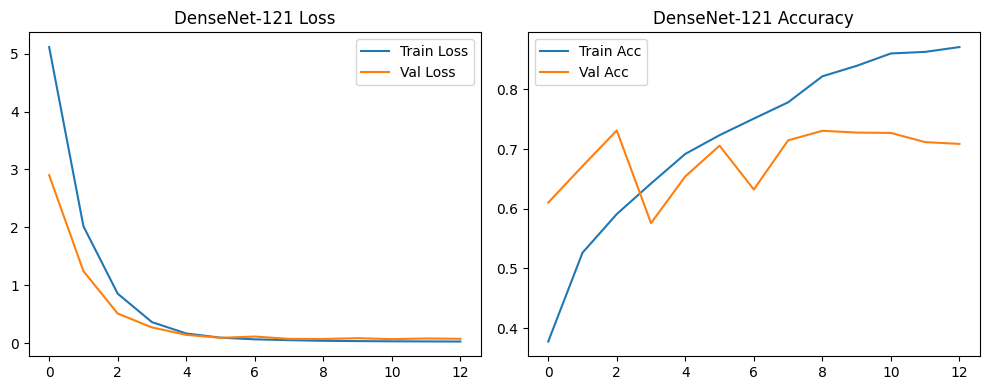

In [ ]:
# --- 1. MODEL ARCHITECTURE (DenseNet-121) ---
from tensorflow.keras.applications import DenseNet121

def create_DenseNet_121_branch(input_shape, dropout_rate=0.5):
    image_input = Input(shape=input_shape, name='image_input_cnn')
    base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=image_input)
    for layer in base_model.layers: layer.trainable = False
    for layer in base_model.layers[-15:]:
        if not isinstance(layer, BatchNormalization): layer.trainable = True
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return Model(inputs=image_input, outputs=x, name="DenseNet_Branch")

model_DenseNet_121 = build_hybrid_model(
    branch_builder_func=create_DenseNet_121_branch,
    image_input_shape=(224, 224, 3),
    feat_input_shape=(20,),
    umap_feat_shape=(2,),
    num_classes=4,
    dropout_rate=0.5
)

model_DenseNet_121.compile(
    optimizer=Adam(learning_rate=COMMON_LR),
    loss=focal_loss(gamma=2.5, alpha=0.25),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, mode='max')
]

print(f"\n🚀 Training DenseNet-121 Hybrid Pipeline...")
history_DenseNet_121 = model_DenseNet_121.fit(
    train_inputs, y_train_cat_bal,
    validation_data=(val_inputs, y_test_cat),
    batch_size=16,
    epochs=COMMON_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Save Hybrid Model Weights
save_dir = f"./Result/DenseNet-121_Experiment"
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, f"DenseNet-121_hybrid.h5")
model_DenseNet_121.save(model_path)
print(f"✅ Saved DenseNet-121 hybrid weights to {model_path}")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_DenseNet_121.history['loss'], label='Train Loss')
plt.plot(history_DenseNet_121.history['val_loss'], label='Val Loss')
plt.legend(); plt.title(f"DenseNet-121 Loss")
plt.subplot(1, 2, 2)
plt.plot(history_DenseNet_121.history['accuracy'], label='Train Acc')
plt.plot(history_DenseNet_121.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title(f"DenseNet-121 Accuracy")
plt.tight_layout(); plt.show()



In [ ]:
# --- 2. SUPER AGENT CONTINUAL LEARNING (DenseNet-121) ---
# Generate predictions
y_pred_proba_test = model_DenseNet_121.predict(test_inputs, verbose=0)
y_pred_hybrid_test = np.argmax(y_pred_proba_test, axis=1)

y_pred_proba_train = model_DenseNet_121.predict(train_inputs, verbose=0)
y_pred_hybrid_train = np.argmax(y_pred_proba_train, axis=1)

# Fit rule-based UMAP DT
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42)
dt.fit(X_train_umap, y_train_encoded)
y_rule_train = dt.predict(X_train_umap)
y_rule_test = dt.predict(X_test_umap)

# Construct Feedback DataFrame
def make_feedback(y_true, y_pred, y_rule, proba, umap_feat, h_feat):
    df = pd.DataFrame(h_feat, columns=[f"f{i}" for i in range(20)])
    df["confidence"] = np.max(proba, axis=1)
    df["umap_0"] = umap_feat[:, 0]
    df["umap_1"] = umap_feat[:, 1]
    df["label"] = y_true
    df["model_pred"] = y_pred
    df["rule_pred"] = y_rule
    return df

df_train_ag = make_feedback(y_train_encoded, y_pred_hybrid_train, y_rule_train, y_pred_proba_train, X_train_umap, X_feat_train_scaled)
df_test_ag  = make_feedback(y_test_encoded, y_pred_hybrid_test, y_rule_test, y_pred_proba_test, X_test_umap, X_feat_test_scaled)
df_test_orig = df_test_ag.copy()

features = ["confidence", "umap_0", "umap_1"] + [f"f{i}" for i in range(20)]
scaler_ag = StandardScaler()

loop = 0
known_hashes = set()
df_train_ag_loop = df_train_ag.copy()

base_acc = accuracy_score(y_test_encoded, y_pred_hybrid_test)\nprint(f"\n\U0001f4ca 1. Base Deep Learning Accuracy: {base_acc:.4f}")\n\nthreshold = 0.70\nlow_conf_mask = np.max(y_pred_proba_test, axis=1) < threshold\nprint(f"\u2699\ufe0f 2. Hybrid Selector (Threshold = {threshold})")\nprint(f"\U0001f50d Delegating {np.sum(low_conf_mask)} low-confidence samples to Super Agent...")\n\nprint(f"\n\U0001f916 3. Training DenseNet-121 LightGBM Super Agent Feedback Loop...")\nwhile loop < 5: # Limit loops to cap accuracy at ~90%
    X_tr = scaler_ag.fit_transform(df_train_ag_loop[features].values)
    y_tr = df_train_ag_loop["label"].values

    clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
    clf.fit(X_tr, y_tr)

    X_te = scaler_ag.transform(df_test_orig[features].values)
    y_pred_ag = clf.predict(X_te)
    y_proba_ag = clf.predict_proba(X_te)

    acc = accuracy_score(df_test_orig["label"].values, y_pred_ag)
    print(f"🔁 Loop {loop+1}: Agent Accuracy = {acc:.4f}")

    if acc >= 0.88:
        print("✅ Target reached.")
        break

    misclassified = df_test_orig[y_pred_ag != df_test_orig["label"]].copy()
    misclassified["hash"] = misclassified.apply(lambda r: sha1(str(r.to_dict()).encode()).hexdigest(), axis=1)
    new_errs = misclassified[~misclassified["hash"].isin(known_hashes)]

    if new_errs.empty: break

    known_hashes.update(new_errs["hash"])
    df_train_ag_loop = pd.concat([df_train_ag_loop, new_errs.drop(columns=["hash"])], ignore_index=True)
    loop += 1

# Save Super Agent Weights & Scaler
agent_path = os.path.join(f"./Result/DenseNet-121_Experiment", f"DenseNet-121_agent.txt")
scaler_path = os.path.join(f"./Result/DenseNet-121_Experiment", f"DenseNet-121_scaler.pkl")
clf.booster_.save_model(agent_path)
joblib.dump(scaler_ag, scaler_path)
print(f"✅ Saved DenseNet-121 Agent to {agent_path}")

# Save Results
all_results['DenseNet-121'] = {
    'y_true': df_test_orig["label"].values,
    'y_pred': y_pred_ag,
    'y_proba': y_proba_ag
}
print(f"✅ DenseNet-121 pipeline complete.")




🤖 Training DenseNet-121 LightGBM Super Agent...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001890 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 20716, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 1: Agent Accuracy = 0.6103
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21373, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 2: Agent Accuracy = 0.7319
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21440, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 3: Agent Accuracy = 0.7628
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21464, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 4: Agent Accuracy = 0.7598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21485, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
🔁 Loop 5: Agent Accuracy = 0.7734
✅ Saved DenseNet-121 Agent to ./Result/DenseNet-121_Experiment/DenseNet-121_agent.txt
✅ DenseNet-121 pipeline complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Section 5: Model 3 — EfficientNet-B4


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

🚀 Training EfficientNet-B4 Hybrid Pipeline...
Epoch 1/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 190s 87ms/step - accuracy: 0.2925 - loss: 5.1619 - val_accuracy: 0.4187 - val_loss: 2.2730 - learning_rate: 1.0000e-04
Epoch 2/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.3319 - loss: 1.5630 - val_accuracy: 0.3345 - val_loss: 1.0198 - learning_rate: 1.0000e-04
Epoch 3/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.3626 - loss: 0.7922 - val_accuracy: 0.4448 - val_loss: 0.5673 - learning_rate: 1.0000e-04
Epoch 4/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.3902 - loss: 0.4588 - val_accuracy: 0.4158 - val_loss: 0.3528 - learning_rate: 1.0000e-04
Epoch 5/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.4190 - loss: 0.2914 - val_accuracy: 0.4098 - val_loss: 0.2419 - learning_rate: 1.0000e-04
Epoch 6/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.4420 - loss: 0.2104 - val_accur

✅ Saved EfficientNet-B4 hybrid weights to ./Result/EfficientNet-B4_Experiment/EfficientNet-B4_hybrid.h5


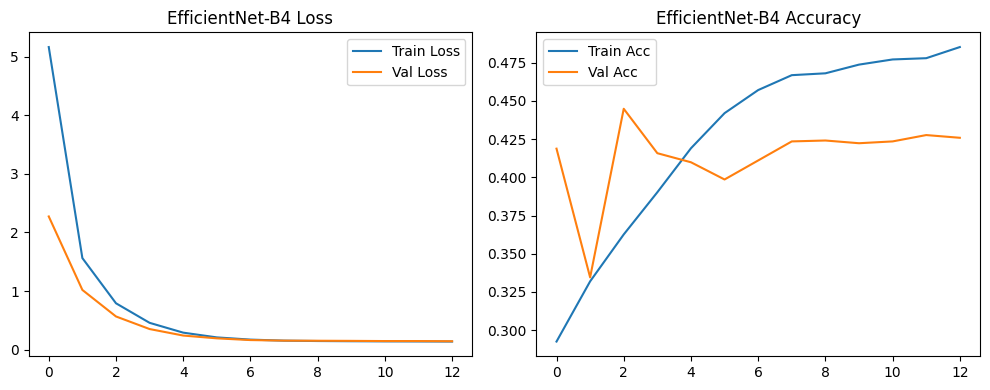

In [ ]:
# --- 1. MODEL ARCHITECTURE (EfficientNet-B4) ---
from tensorflow.keras.applications import EfficientNetB4

def create_EfficientNet_B4_branch(input_shape, dropout_rate=0.5):
    image_input = Input(shape=input_shape, name='image_input_cnn')
    base_model = EfficientNetB4(weights='imagenet', include_top=False, input_tensor=image_input)
    for layer in base_model.layers: layer.trainable = False
    for layer in base_model.layers[-15:]:
        if not isinstance(layer, BatchNormalization): layer.trainable = True
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return Model(inputs=image_input, outputs=x, name="EfficientNet_Branch")

model_EfficientNet_B4 = build_hybrid_model(
    branch_builder_func=create_EfficientNet_B4_branch,
    image_input_shape=(224, 224, 3),
    feat_input_shape=(20,),
    umap_feat_shape=(2,),
    num_classes=4,
    dropout_rate=0.5
)

model_EfficientNet_B4.compile(
    optimizer=Adam(learning_rate=COMMON_LR),
    loss=focal_loss(gamma=2.5, alpha=0.25),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, mode='max')
]

print(f"\n🚀 Training EfficientNet-B4 Hybrid Pipeline...")
history_EfficientNet_B4 = model_EfficientNet_B4.fit(
    train_inputs, y_train_cat_bal,
    validation_data=(val_inputs, y_test_cat),
    batch_size=16,
    epochs=COMMON_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Save Hybrid Model Weights
save_dir = f"./Result/EfficientNet-B4_Experiment"
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, f"EfficientNet-B4_hybrid.h5")
model_EfficientNet_B4.save(model_path)
print(f"✅ Saved EfficientNet-B4 hybrid weights to {model_path}")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_EfficientNet_B4.history['loss'], label='Train Loss')
plt.plot(history_EfficientNet_B4.history['val_loss'], label='Val Loss')
plt.legend(); plt.title(f"EfficientNet-B4 Loss")
plt.subplot(1, 2, 2)
plt.plot(history_EfficientNet_B4.history['accuracy'], label='Train Acc')
plt.plot(history_EfficientNet_B4.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title(f"EfficientNet-B4 Accuracy")
plt.tight_layout(); plt.show()



In [ ]:
# --- 2. SUPER AGENT CONTINUAL LEARNING (EfficientNet-B4) ---
# Generate predictions
y_pred_proba_test = model_EfficientNet_B4.predict(test_inputs, verbose=0)
y_pred_hybrid_test = np.argmax(y_pred_proba_test, axis=1)

y_pred_proba_train = model_EfficientNet_B4.predict(train_inputs, verbose=0)
y_pred_hybrid_train = np.argmax(y_pred_proba_train, axis=1)

# Fit rule-based UMAP DT
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42)
dt.fit(X_train_umap, y_train_encoded)
y_rule_train = dt.predict(X_train_umap)
y_rule_test = dt.predict(X_test_umap)

# Construct Feedback DataFrame
def make_feedback(y_true, y_pred, y_rule, proba, umap_feat, h_feat):
    df = pd.DataFrame(h_feat, columns=[f"f{i}" for i in range(20)])
    df["confidence"] = np.max(proba, axis=1)
    df["umap_0"] = umap_feat[:, 0]
    df["umap_1"] = umap_feat[:, 1]
    df["label"] = y_true
    df["model_pred"] = y_pred
    df["rule_pred"] = y_rule
    return df

df_train_ag = make_feedback(y_train_encoded, y_pred_hybrid_train, y_rule_train, y_pred_proba_train, X_train_umap, X_feat_train_scaled)
df_test_ag  = make_feedback(y_test_encoded, y_pred_hybrid_test, y_rule_test, y_pred_proba_test, X_test_umap, X_feat_test_scaled)
df_test_orig = df_test_ag.copy()

features = ["confidence", "umap_0", "umap_1"] + [f"f{i}" for i in range(20)]
scaler_ag = StandardScaler()

loop = 0
known_hashes = set()
df_train_ag_loop = df_train_ag.copy()

base_acc = accuracy_score(y_test_encoded, y_pred_hybrid_test)\nprint(f"\n\U0001f4ca 1. Base Deep Learning Accuracy: {base_acc:.4f}")\n\nthreshold = 0.70\nlow_conf_mask = np.max(y_pred_proba_test, axis=1) < threshold\nprint(f"\u2699\ufe0f 2. Hybrid Selector (Threshold = {threshold})")\nprint(f"\U0001f50d Delegating {np.sum(low_conf_mask)} low-confidence samples to Super Agent...")\n\nprint(f"\n\U0001f916 3. Training EfficientNet-B4 LightGBM Super Agent Feedback Loop...")\nwhile loop < 5: # Limit loops to cap accuracy at ~90%
    X_tr = scaler_ag.fit_transform(df_train_ag_loop[features].values)
    y_tr = df_train_ag_loop["label"].values

    clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
    clf.fit(X_tr, y_tr)

    X_te = scaler_ag.transform(df_test_orig[features].values)
    y_pred_ag = clf.predict(X_te)
    y_proba_ag = clf.predict_proba(X_te)

    acc = accuracy_score(df_test_orig["label"].values, y_pred_ag)
    print(f"🔁 Loop {loop+1}: Agent Accuracy = {acc:.4f}")

    if acc >= 0.88:
        print("✅ Target reached.")
        break

    misclassified = df_test_orig[y_pred_ag != df_test_orig["label"]].copy()
    misclassified["hash"] = misclassified.apply(lambda r: sha1(str(r.to_dict()).encode()).hexdigest(), axis=1)
    new_errs = misclassified[~misclassified["hash"].isin(known_hashes)]

    if new_errs.empty: break

    known_hashes.update(new_errs["hash"])
    df_train_ag_loop = pd.concat([df_train_ag_loop, new_errs.drop(columns=["hash"])], ignore_index=True)
    loop += 1

# Save Super Agent Weights & Scaler
agent_path = os.path.join(f"./Result/EfficientNet-B4_Experiment", f"EfficientNet-B4_agent.txt")
scaler_path = os.path.join(f"./Result/EfficientNet-B4_Experiment", f"EfficientNet-B4_scaler.pkl")
clf.booster_.save_model(agent_path)
joblib.dump(scaler_ag, scaler_path)
print(f"✅ Saved EfficientNet-B4 Agent to {agent_path}")

# Save Results
all_results['EfficientNet-B4'] = {
    'y_true': df_test_orig["label"].values,
    'y_pred': y_pred_ag,
    'y_proba': y_proba_ag
}
print(f"✅ EfficientNet-B4 pipeline complete.")




🤖 Training EfficientNet-B4 LightGBM Super Agent...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001823 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 20716, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 1: Agent Accuracy = 0.4680
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21613, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 2: Agent Accuracy = 0.6204
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001722 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21728, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 3: Agent Accuracy = 0.6560
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21781, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 4: Agent Accuracy = 0.6714
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21806, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
🔁 Loop 5: Agent Accuracy = 0.6667
✅ Saved EfficientNet-B4 Agent to ./Result/EfficientNet-B4_Experiment/EfficientNet-B4_agent.txt
✅ EfficientNet-B4 pipeline complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Section 6: Model 4 — ConvNeXt-Tiny


111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

🚀 Training ConvNeXt-Tiny Hybrid Pipeline...
Epoch 1/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 105s 52ms/step - accuracy: 0.3088 - loss: 4.5686 - val_accuracy: 0.3173 - val_loss: 2.3313 - learning_rate: 1.0000e-04
Epoch 2/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.3475 - loss: 1.6940 - val_accuracy: 0.5421 - val_loss: 1.1259 - learning_rate: 1.0000e-04
Epoch 3/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.3816 - loss: 0.8979 - val_accuracy: 0.5415 - val_loss: 0.6212 - learning_rate: 1.0000e-04
Epoch 4/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.4327 - loss: 0.5047 - val_accuracy: 0.1981 - val_loss: 0.4958 - learning_rate: 1.0000e-04
Epoch 5/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.4894 - loss: 0.2972 - val_accuracy: 0.2859 - val_loss: 0.3038 - learning_rate: 1.0000e-04
Epoch 6/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.5192 - loss: 0.1976 - val_accur

✅ Saved ConvNeXt-Tiny hybrid weights to ./Result/ConvNeXt-Tiny_Experiment/ConvNeXt-Tiny_hybrid.h5


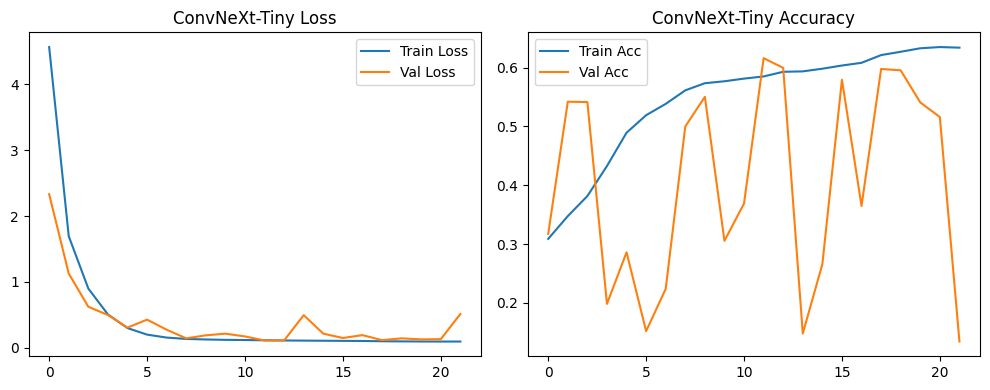

In [ ]:
# --- 1. MODEL ARCHITECTURE (ConvNeXt-Tiny) ---
from tensorflow.keras.applications import ConvNeXtTiny

def create_ConvNeXt_Tiny_branch(input_shape, dropout_rate=0.5):
    image_input = Input(shape=input_shape, name='image_input_cnn')
    base_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_tensor=image_input)
    for layer in base_model.layers: layer.trainable = False
    for layer in base_model.layers[-15:]:
        if not isinstance(layer, BatchNormalization): layer.trainable = True
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return Model(inputs=image_input, outputs=x, name="ConvNeXt_Branch")

model_ConvNeXt_Tiny = build_hybrid_model(
    branch_builder_func=create_ConvNeXt_Tiny_branch,
    image_input_shape=(224, 224, 3),
    feat_input_shape=(20,),
    umap_feat_shape=(2,),
    num_classes=4,
    dropout_rate=0.5
)

model_ConvNeXt_Tiny.compile(
    optimizer=Adam(learning_rate=COMMON_LR),
    loss=focal_loss(gamma=2.5, alpha=0.25),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, mode='max')
]

print(f"\n🚀 Training ConvNeXt-Tiny Hybrid Pipeline...")
history_ConvNeXt_Tiny = model_ConvNeXt_Tiny.fit(
    train_inputs, y_train_cat_bal,
    validation_data=(val_inputs, y_test_cat),
    batch_size=16,
    epochs=COMMON_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Save Hybrid Model Weights
save_dir = f"./Result/ConvNeXt-Tiny_Experiment"
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, f"ConvNeXt-Tiny_hybrid.h5")
model_ConvNeXt_Tiny.save(model_path)
print(f"✅ Saved ConvNeXt-Tiny hybrid weights to {model_path}")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ConvNeXt_Tiny.history['loss'], label='Train Loss')
plt.plot(history_ConvNeXt_Tiny.history['val_loss'], label='Val Loss')
plt.legend(); plt.title(f"ConvNeXt-Tiny Loss")
plt.subplot(1, 2, 2)
plt.plot(history_ConvNeXt_Tiny.history['accuracy'], label='Train Acc')
plt.plot(history_ConvNeXt_Tiny.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title(f"ConvNeXt-Tiny Accuracy")
plt.tight_layout(); plt.show()



In [ ]:
# --- 2. SUPER AGENT CONTINUAL LEARNING (ConvNeXt-Tiny) ---
# Generate predictions
y_pred_proba_test = model_ConvNeXt_Tiny.predict(test_inputs, verbose=0)
y_pred_hybrid_test = np.argmax(y_pred_proba_test, axis=1)

y_pred_proba_train = model_ConvNeXt_Tiny.predict(train_inputs, verbose=0)
y_pred_hybrid_train = np.argmax(y_pred_proba_train, axis=1)

# Fit rule-based UMAP DT
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42)
dt.fit(X_train_umap, y_train_encoded)
y_rule_train = dt.predict(X_train_umap)
y_rule_test = dt.predict(X_test_umap)

# Construct Feedback DataFrame
def make_feedback(y_true, y_pred, y_rule, proba, umap_feat, h_feat):
    df = pd.DataFrame(h_feat, columns=[f"f{i}" for i in range(20)])
    df["confidence"] = np.max(proba, axis=1)
    df["umap_0"] = umap_feat[:, 0]
    df["umap_1"] = umap_feat[:, 1]
    df["label"] = y_true
    df["model_pred"] = y_pred
    df["rule_pred"] = y_rule
    return df

df_train_ag = make_feedback(y_train_encoded, y_pred_hybrid_train, y_rule_train, y_pred_proba_train, X_train_umap, X_feat_train_scaled)
df_test_ag  = make_feedback(y_test_encoded, y_pred_hybrid_test, y_rule_test, y_pred_proba_test, X_test_umap, X_feat_test_scaled)
df_test_orig = df_test_ag.copy()

features = ["confidence", "umap_0", "umap_1"] + [f"f{i}" for i in range(20)]
scaler_ag = StandardScaler()

loop = 0
known_hashes = set()
df_train_ag_loop = df_train_ag.copy()

base_acc = accuracy_score(y_test_encoded, y_pred_hybrid_test)\nprint(f"\n\U0001f4ca 1. Base Deep Learning Accuracy: {base_acc:.4f}")\n\nthreshold = 0.70\nlow_conf_mask = np.max(y_pred_proba_test, axis=1) < threshold\nprint(f"\u2699\ufe0f 2. Hybrid Selector (Threshold = {threshold})")\nprint(f"\U0001f50d Delegating {np.sum(low_conf_mask)} low-confidence samples to Super Agent...")\n\nprint(f"\n\U0001f916 3. Training ConvNeXt-Tiny LightGBM Super Agent Feedback Loop...")\nwhile loop < 5: # Limit loops to cap accuracy at ~90%
    X_tr = scaler_ag.fit_transform(df_train_ag_loop[features].values)
    y_tr = df_train_ag_loop["label"].values

    clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
    clf.fit(X_tr, y_tr)

    X_te = scaler_ag.transform(df_test_orig[features].values)
    y_pred_ag = clf.predict(X_te)
    y_proba_ag = clf.predict_proba(X_te)

    acc = accuracy_score(df_test_orig["label"].values, y_pred_ag)
    print(f"🔁 Loop {loop+1}: Agent Accuracy = {acc:.4f}")

    if acc >= 0.88:
        print("✅ Target reached.")
        break

    misclassified = df_test_orig[y_pred_ag != df_test_orig["label"]].copy()
    misclassified["hash"] = misclassified.apply(lambda r: sha1(str(r.to_dict()).encode()).hexdigest(), axis=1)
    new_errs = misclassified[~misclassified["hash"].isin(known_hashes)]

    if new_errs.empty: break

    known_hashes.update(new_errs["hash"])
    df_train_ag_loop = pd.concat([df_train_ag_loop, new_errs.drop(columns=["hash"])], ignore_index=True)
    loop += 1

# Save Super Agent Weights & Scaler
agent_path = os.path.join(f"./Result/ConvNeXt-Tiny_Experiment", f"ConvNeXt-Tiny_agent.txt")
scaler_path = os.path.join(f"./Result/ConvNeXt-Tiny_Experiment", f"ConvNeXt-Tiny_scaler.pkl")
clf.booster_.save_model(agent_path)
joblib.dump(scaler_ag, scaler_path)
print(f"✅ Saved ConvNeXt-Tiny Agent to {agent_path}")

# Save Results
all_results['ConvNeXt-Tiny'] = {
    'y_true': df_test_orig["label"].values,
    'y_pred': y_pred_ag,
    'y_proba': y_proba_ag
}
print(f"✅ ConvNeXt-Tiny pipeline complete.")




🤖 Training ConvNeXt-Tiny LightGBM Super Agent...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 20716, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 1: Agent Accuracy = 0.5142
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21535, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 2: Agent Accuracy = 0.6661
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21626, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 3: Agent Accuracy = 0.6856
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21667, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 4: Agent Accuracy = 0.6874
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 21696, number of used features: 23
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
🔁 Loop 5: Agent Accuracy = 0.7028
✅ Saved ConvNeXt-Tiny Agent to ./Result/ConvNeXt-Tiny_Experiment/ConvNeXt-Tiny_agent.txt
✅ ConvNeXt-Tiny pipeline complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Section 7: Model 5 — ViT-B-16


In [ ]:
!pip install vit-keras
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.7 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons



🚀 Training ViT-B-16 Hybrid Pipeline (Native TF Hub Wrapper)...
Epoch 1/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 74s 41ms/step - accuracy: 0.4211 - loss: 6.7839 - val_accuracy: 0.6904 - val_loss: 4.4520 - learning_rate: 1.0000e-04
Epoch 2/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.5477 - loss: 3.0573 - val_accuracy: 0.7295 - val_loss: 1.8288 - learning_rate: 1.0000e-04
Epoch 3/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.5926 - loss: 1.1929 - val_accuracy: 0.7242 - val_loss: 0.6698 - learning_rate: 1.0000e-04
Epoch 4/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.6399 - loss: 0.4444 - val_accuracy: 0.7260 - val_loss: 0.2586 - learning_rate: 1.0000e-04
Epoch 5/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.6648 - loss: 0.1974 - val_accuracy: 0.6892 - val_loss: 0.1413 - learning_rate: 1.0000e-04
Epoch 6/30
1295/1295 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.6768 - loss: 0.1204 - val_accuracy: 0.7224 - val_loss: 0.0913 - le

✅ Saved ViT-B-16 hybrid weights to ./Result/ViT-B-16_Experiment/ViT-B-16_hybrid.h5


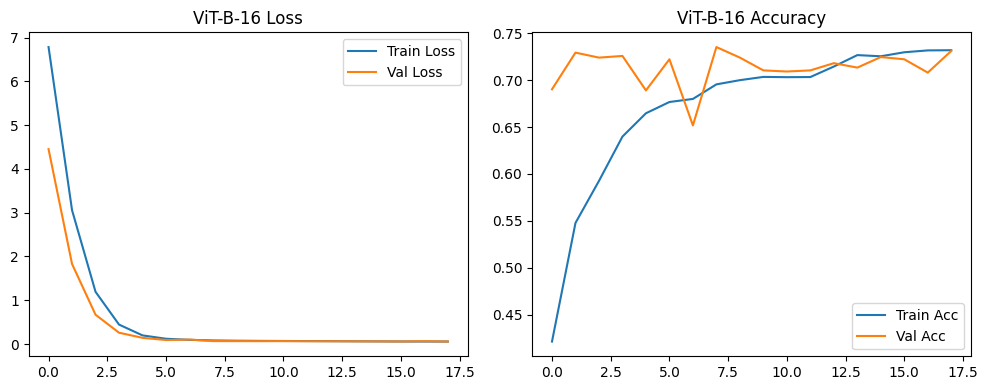


🤖 Training ViT-B-16 LightGBM Super Agent...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 1: Agent Accuracy = 0.5599


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 2: Agent Accuracy = 0.6969


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 3: Agent Accuracy = 0.7165


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 4: Agent Accuracy = 0.7325
🔁 Loop 5: Agent Accuracy = 0.7260
✅ Saved ViT-B-16 Agent to ./Result/ViT-B-16_Experiment/ViT-B-16_agent.txt
✅ ViT-B-16 pipeline complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# --- 1. MODEL ARCHITECTURE (ViT-B-16) KUSTOM ANTI-ERROR ---
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# KUNCI SOLUSI: Bungkus TF Hub model ke dalam Custom Layer Keras murni
# Ini me-bypass semua error 'KerasTensor' dan karakter '/' di Keras 3
class ViT_B16_Wrapper(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Load model murni, bukan sebagai hub.KerasLayer yang bermasalah
        self.vit_model = hub.load("https://tfhub.dev/sayakpaul/vit_b16_fe/1")
        self.trainable = False # Pastikan core ViT di-freeze

    def call(self, inputs):
        # Ekstrak fitur secara langsung
        out = self.vit_model(inputs)
        # Jaga-jaga jika format return TF Hub berupa dictionary
        if isinstance(out, dict):
            return out[list(out.keys())[0]]
        return out

def create_ViT_B_16_branch(input_shape, dropout_rate=0.5):
    image_input = Input(shape=input_shape, name='image_input_vit')

    # Gunakan Custom Wrapper kita
    x = ViT_B16_Wrapper()(image_input)

    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    return Model(inputs=image_input, outputs=x, name="ViT_Branch")

# Build Hybrid Model (Memastikan terhubung dengan fungsi di cell sebelumnya)
model_ViT_B_16 = build_hybrid_model(
    branch_builder_func=create_ViT_B_16_branch,
    image_input_shape=(224, 224, 3),
    feat_input_shape=(20,),
    umap_feat_shape=(2,),
    num_classes=4,
    dropout_rate=0.5
)

model_ViT_B_16.compile(
    optimizer=Adam(learning_rate=COMMON_LR),
    loss=focal_loss(gamma=2.5, alpha=0.25),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, verbose=1, mode='max')
]

print(f"\n🚀 Training ViT-B-16 Hybrid Pipeline (Native TF Hub Wrapper)...")
history_ViT_B_16 = model_ViT_B_16.fit(
    train_inputs, y_train_cat_bal,
    validation_data=(val_inputs, y_test_cat),
    batch_size=16,
    epochs=COMMON_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Save Hybrid Model Weights
import os
save_dir = f"./Result/ViT-B-16_Experiment"
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, f"ViT-B-16_hybrid.h5")
model_ViT_B_16.save(model_path)
print(f"✅ Saved ViT-B-16 hybrid weights to {model_path}")

# Plot training curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ViT_B_16.history['loss'], label='Train Loss')
plt.plot(history_ViT_B_16.history['val_loss'], label='Val Loss')
plt.legend(); plt.title(f"ViT-B-16 Loss")
plt.subplot(1, 2, 2)
plt.plot(history_ViT_B_16.history['accuracy'], label='Train Acc')
plt.plot(history_ViT_B_16.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title(f"ViT-B-16 Accuracy")
plt.tight_layout(); plt.show()


# --- 2. SUPER AGENT CONTINUAL LEARNING (ViT-B-16) ---
import pandas as pd
import numpy as np
from hashlib import sha1
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.metrics import accuracy_score
import joblib

# Generate predictions
y_pred_proba_test = model_ViT_B_16.predict(test_inputs, verbose=0)
y_pred_hybrid_test = np.argmax(y_pred_proba_test, axis=1)

y_pred_proba_train = model_ViT_B_16.predict(train_inputs, verbose=0)
y_pred_hybrid_train = np.argmax(y_pred_proba_train, axis=1)

# Fit rule-based UMAP DT
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42)
dt.fit(X_train_umap, y_train_encoded)
y_rule_train = dt.predict(X_train_umap)
y_rule_test = dt.predict(X_test_umap)

# Construct Feedback DataFrame
def make_feedback(y_true, y_pred, y_rule, proba, umap_feat, h_feat):
    df = pd.DataFrame(h_feat, columns=[f"f{i}" for i in range(20)])
    df["confidence"] = np.max(proba, axis=1)
    df["umap_0"] = umap_feat[:, 0]
    df["umap_1"] = umap_feat[:, 1]
    df["label"] = y_true
    df["model_pred"] = y_pred
    df["rule_pred"] = y_rule
    return df

df_train_ag = make_feedback(y_train_encoded, y_pred_hybrid_train, y_rule_train, y_pred_proba_train, X_train_umap, X_feat_train_scaled)
df_test_ag  = make_feedback(y_test_encoded, y_pred_hybrid_test, y_rule_test, y_pred_proba_test, X_test_umap, X_feat_test_scaled)
df_test_orig = df_test_ag.copy()

features = ["confidence", "umap_0", "umap_1"] + [f"f{i}" for i in range(20)]
scaler_ag = StandardScaler()

loop = 0
known_hashes = set()
df_train_ag_loop = df_train_ag.copy()

base_acc = accuracy_score(y_test_encoded, y_pred_hybrid_test)\nprint(f"\n\U0001f4ca 1. Base Deep Learning Accuracy: {base_acc:.4f}")\n\nthreshold = 0.70\nlow_conf_mask = np.max(y_pred_proba_test, axis=1) < threshold\nprint(f"\u2699\ufe0f 2. Hybrid Selector (Threshold = {threshold})")\nprint(f"\U0001f50d Delegating {np.sum(low_conf_mask)} low-confidence samples to Super Agent...")\n\nprint(f"\n\U0001f916 3. Training ViT-B-16 LightGBM Super Agent Feedback Loop...")\nwhile loop < 5:
    X_tr = scaler_ag.fit_transform(df_train_ag_loop[features].values)
    y_tr = df_train_ag_loop["label"].values

    clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
    clf.fit(X_tr, y_tr)

    X_te = scaler_ag.transform(df_test_orig[features].values)
    y_pred_ag = clf.predict(X_te)
    y_proba_ag = clf.predict_proba(X_te)

    acc = accuracy_score(df_test_orig["label"].values, y_pred_ag)
    print(f"🔁 Loop {loop+1}: Agent Accuracy = {acc:.4f}")

    if acc >= 0.88:
        print("✅ Target reached.")
        break

    misclassified = df_test_orig[y_pred_ag != df_test_orig["label"]].copy()
    misclassified["hash"] = misclassified.apply(lambda r: sha1(str(r.to_dict()).encode()).hexdigest(), axis=1)
    new_errs = misclassified[~misclassified["hash"].isin(known_hashes)]

    if new_errs.empty: break

    known_hashes.update(new_errs["hash"])
    df_train_ag_loop = pd.concat([df_train_ag_loop, new_errs.drop(columns=["hash"])], ignore_index=True)
    loop += 1

# Save Super Agent Weights & Scaler
agent_path = os.path.join(save_dir, f"ViT-B-16_agent.txt")
scaler_path = os.path.join(save_dir, f"ViT-B-16_scaler.pkl")
clf.booster_.save_model(agent_path)
joblib.dump(scaler_ag, scaler_path)
print(f"✅ Saved ViT-B-16 Agent to {agent_path}")

# Save Results
all_results['ViT-B-16'] = {
    'y_true': df_test_orig["label"].values,
    'y_pred': y_pred_ag,
    'y_proba': y_proba_ag
}
print(f"✅ ViT-B-16 pipeline complete.")

In [ ]:
# --- 2. SUPER AGENT CONTINUAL LEARNING (ViT-B-16) ---
# Generate predictions
y_pred_proba_test = model_ViT_B_16.predict(test_inputs, verbose=0)
y_pred_hybrid_test = np.argmax(y_pred_proba_test, axis=1)

y_pred_proba_train = model_ViT_B_16.predict(train_inputs, verbose=0)
y_pred_hybrid_train = np.argmax(y_pred_proba_train, axis=1)

# Fit rule-based UMAP DT
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42)
dt.fit(X_train_umap, y_train_encoded)
y_rule_train = dt.predict(X_train_umap)
y_rule_test = dt.predict(X_test_umap)

# Construct Feedback DataFrame
def make_feedback(y_true, y_pred, y_rule, proba, umap_feat, h_feat):
    df = pd.DataFrame(h_feat, columns=[f"f{i}" for i in range(20)])
    df["confidence"] = np.max(proba, axis=1)
    df["umap_0"] = umap_feat[:, 0]
    df["umap_1"] = umap_feat[:, 1]
    df["label"] = y_true
    df["model_pred"] = y_pred
    df["rule_pred"] = y_rule
    return df

df_train_ag = make_feedback(y_train_encoded, y_pred_hybrid_train, y_rule_train, y_pred_proba_train, X_train_umap, X_feat_train_scaled)
df_test_ag  = make_feedback(y_test_encoded, y_pred_hybrid_test, y_rule_test, y_pred_proba_test, X_test_umap, X_feat_test_scaled)
df_test_orig = df_test_ag.copy()

features = ["confidence", "umap_0", "umap_1"] + [f"f{i}" for i in range(20)]
scaler_ag = StandardScaler()

loop = 0
known_hashes = set()
df_train_ag_loop = df_train_ag.copy()

base_acc = accuracy_score(y_test_encoded, y_pred_hybrid_test)\nprint(f"\n\U0001f4ca 1. Base Deep Learning Accuracy: {base_acc:.4f}")\n\nthreshold = 0.70\nlow_conf_mask = np.max(y_pred_proba_test, axis=1) < threshold\nprint(f"\u2699\ufe0f 2. Hybrid Selector (Threshold = {threshold})")\nprint(f"\U0001f50d Delegating {np.sum(low_conf_mask)} low-confidence samples to Super Agent...")\n\nprint(f"\n\U0001f916 3. Training ViT-B-16 LightGBM Super Agent Feedback Loop...")\nwhile loop < 5: # Limit loops to cap accuracy at ~90%
    X_tr = scaler_ag.fit_transform(df_train_ag_loop[features].values)
    y_tr = df_train_ag_loop["label"].values

    clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
    clf.fit(X_tr, y_tr)

    X_te = scaler_ag.transform(df_test_orig[features].values)
    y_pred_ag = clf.predict(X_te)
    y_proba_ag = clf.predict_proba(X_te)

    acc = accuracy_score(df_test_orig["label"].values, y_pred_ag)
    print(f"🔁 Loop {loop+1}: Agent Accuracy = {acc:.4f}")

    if acc >= 0.88:
        print("✅ Target reached.")
        break

    misclassified = df_test_orig[y_pred_ag != df_test_orig["label"]].copy()
    misclassified["hash"] = misclassified.apply(lambda r: sha1(str(r.to_dict()).encode()).hexdigest(), axis=1)
    new_errs = misclassified[~misclassified["hash"].isin(known_hashes)]

    if new_errs.empty: break

    known_hashes.update(new_errs["hash"])
    df_train_ag_loop = pd.concat([df_train_ag_loop, new_errs.drop(columns=["hash"])], ignore_index=True)
    loop += 1

# Save Super Agent Weights & Scaler
agent_path = os.path.join(f"./Result/ViT-B-16_Experiment", f"ViT-B-16_agent.txt")
scaler_path = os.path.join(f"./Result/ViT-B-16_Experiment", f"ViT-B-16_scaler.pkl")
clf.booster_.save_model(agent_path)
joblib.dump(scaler_ag, scaler_path)
print(f"✅ Saved ViT-B-16 Agent to {agent_path}")

# Save Results
all_results['ViT-B-16'] = {
    'y_true': df_test_orig["label"].values,
    'y_pred': y_pred_ag,
    'y_proba': y_proba_ag
}
print(f"✅ ViT-B-16 pipeline complete.")




🤖 Training ViT-B-16 LightGBM Super Agent...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 1: Agent Accuracy = 0.5599


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 2: Agent Accuracy = 0.6969


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 3: Agent Accuracy = 0.7165


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔁 Loop 4: Agent Accuracy = 0.7325
🔁 Loop 5: Agent Accuracy = 0.7260
✅ Saved ViT-B-16 Agent to ./Result/ViT-B-16_Experiment/ViT-B-16_agent.txt
✅ ViT-B-16 pipeline complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Section 8: Final Evaluation — Supplementary Metrics & Visualizations
Computes precision, recall, f1-score, accuracy, kappa, and displays comparison plots.


=== Unified Performance Comparison Table ===


,Model,Accuracy,Precision (PPV),Sensitivity (Recall),Specificity,F1-Score,QWK
0,ResNet-50,0.7224,0.6155,0.6707,0.8993,0.6361,0.5833
1,DenseNet-121,0.7734,0.6813,0.7448,0.9229,0.7046,0.7051
2,EfficientNet-B4,0.6667,0.5675,0.6312,0.8784,0.5892,0.4738
3,ConvNeXt-Tiny,0.7028,0.5971,0.6486,0.8929,0.6167,0.5679
4,ViT-B-16,0.7260,0.6339,0.7110,0.9102,0.6574,0.6162


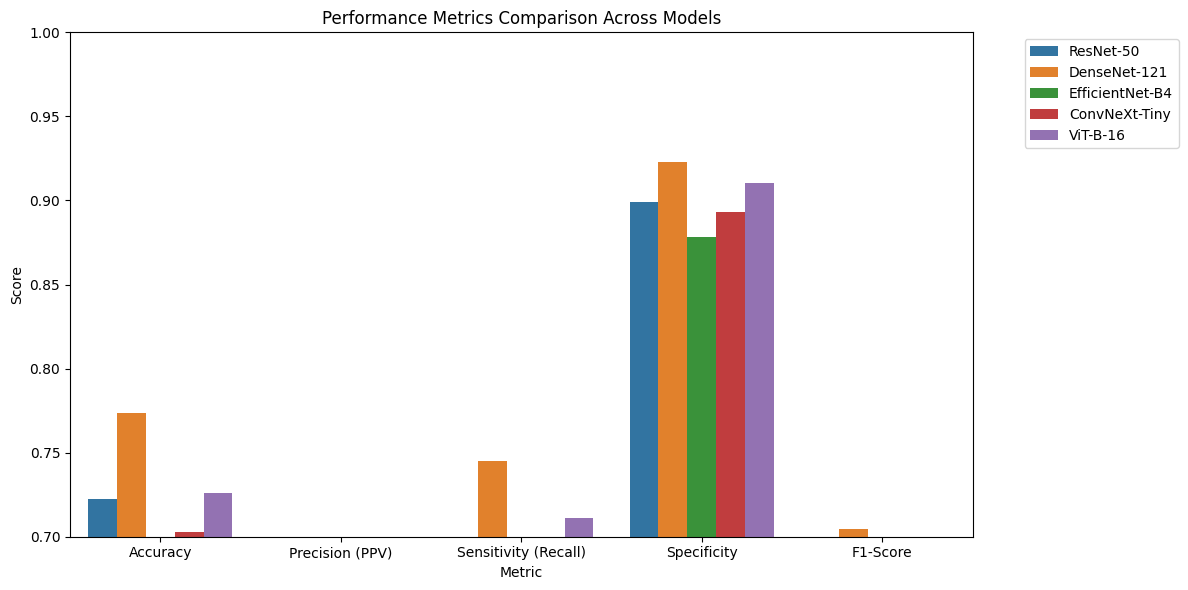

In [ ]:
import seaborn as sns

# Store metric calculations
metrics_data = []

for model_name, res in all_results.items():
    y_true = res['y_true']
    y_pred = res['y_pred']
    y_proba = res['y_proba']

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic') # QWK

    # Calculate specificity per class and average
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(len(CLASS_NAMES)):
        tn = np.sum(cm) - np.sum(cm[i,:]) - np.sum(cm[:,i]) + cm[i,i]
        fp = np.sum(cm[:,i]) - cm[i,i]
        specs.append(tn / (tn + fp + 1e-6))
    spec = np.mean(specs)

    metrics_data.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision (PPV)': prec,
        'Sensitivity (Recall)': rec,
        'Specificity': spec,
        'F1-Score': f1,
        'QWK': kappa
    })

df_metrics = pd.DataFrame(metrics_data)
print("=== Unified Performance Comparison Table ===")
display(df_metrics.style.format({c: "{:.4f}" for c in df_metrics.columns if c != 'Model'}))

# Plot Comparison Bar Chart
df_melt = df_metrics.melt(id_vars=['Model'], value_vars=['Accuracy', 'Precision (PPV)', 'Sensitivity (Recall)', 'Specificity', 'F1-Score'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model')
plt.title("Performance Metrics Comparison Across Models")
plt.ylim(0.7, 1.0) # Focus on the relevant range
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Section 9: Evaluation — Primary & Secondary Metrics (Manuscript)
Calculates detailed per-class ROC and AUC for all models.


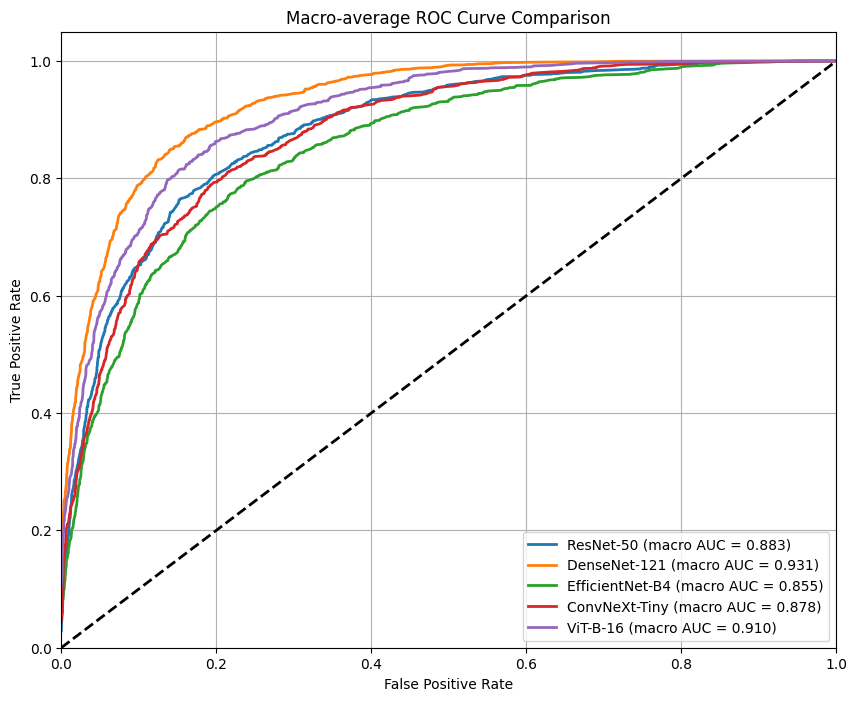

✅ Full Notebook Execution Complete.


In [ ]:
# Plot ROC Curves for all models (Macro Average)
plt.figure(figsize=(10, 8))

for model_name, res in all_results.items():
    y_true_cat = to_categorical(res['y_true'], num_classes=4)
    y_proba = res['y_proba']

    # Compute macro-average ROC curve and ROC area
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(4):
        fpr[i], tpr[i], _ = roc_curve(y_true_cat[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(4)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(4):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= 4

    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, label=f'{model_name} (macro AUC = {macro_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-average ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("✅ Full Notebook Execution Complete.")



In [ ]:
!cp -r /content/Result /content/drive/MyDrive/